
# 🔵🔴 Advanced Weather Data Analysis Notebook

A professional **EDA notebook** featuring:

- 🔵🔴 Blue & Red themed UI (HTML + CSS)
- 📊 Advanced exploratory data analysis
- 🌍 Interactive Plotly visualizations
- 📈 Statistical insights

Dataset used: **weather_dataset_2025.csv**


In [1]:
from IPython.display import HTML

HTML("""
<style>

@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;500;700&display=swap');

body{
font-family:Poppins;
}

.title{
background:linear-gradient(90deg,#0d47a1,#b71c1c);
padding:30px;
border-radius:14px;
color:white;
font-size:42px;
text-align:center;
font-weight:700;
}

.section{
background:#0d47a1;
color:white;
padding:12px;
border-radius:10px;
font-size:24px;
margin-top:30px;
}

.box{
background:#e3f2fd;
border-left:8px solid #b71c1c;
padding:18px;
border-radius:10px;
color:#0d47a1;
font-size:16px;
}

</style>
""")

<div class='title'>Weather Dataset Exploratory Data Analysis</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")


<div class='section'>Load Dataset</div>

In [3]:
df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/weather-dataset/weather_dataset_2025.csv")
df.head()

,Date,City,Temperature_C,Humidity_%,Wind_Speed_km_h,Precipitation_mm,Condition
0,2025-01-01,Riyadh,15.8,94,21.0,0.00,Cloudy
1,2025-01-01,Jeddah,31.5,54,25.3,3.71,Windy
2,2025-01-01,Dammam,30.4,33,8.6,3.14,Partly Cloudy
3,2025-01-01,Dubai,34.0,37,18.7,0.00,Foggy
4,2025-01-01,Doha,28.3,32,6.8,0.00,Rainy


<div class='section'>Dataset Overview</div>

In [4]:
print("Shape:",df.shape)

Shape: (5475, 7)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5475 entries, 0 to 5474
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              5475 non-null   object 
 1   City              5475 non-null   object 
 2   Temperature_C     5475 non-null   float64
 3   Humidity_%        5475 non-null   int64  
 4   Wind_Speed_km_h   5475 non-null   float64
 5   Precipitation_mm  5475 non-null   float64
 6   Condition         5475 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 299.5+ KB


In [6]:
df.describe()

,Temperature_C,Humidity_%,Wind_Speed_km_h,Precipitation_mm
count,5475.000000,5475.000000,5475.000000,5475.000000
mean,24.992311,57.675982,20.045479,3.154093
std,11.545127,21.853563,11.599011,3.624299
min,5.000000,20.000000,0.000000,0.000000
25%,15.000000,39.000000,10.100000,0.000000
50%,25.000000,58.000000,20.000000,1.980000
75%,35.100000,77.000000,30.000000,5.355000
max,45.000000,95.000000,40.000000,21.370000


<div class='section'>Missing Values Analysis</div>

In [7]:
df.isnull().sum()

Date                0
City                0
Temperature_C       0
Humidity_%          0
Wind_Speed_km_h     0
Precipitation_mm    0
Condition           0
dtype: int64

<div class='section'>Data Types</div>

In [8]:
df.dtypes

Date                 object
City                 object
Temperature_C       float64
Humidity_%            int64
Wind_Speed_km_h     float64
Precipitation_mm    float64
Condition            object
dtype: object

<div class='section'>Numerical Feature Correlation</div>

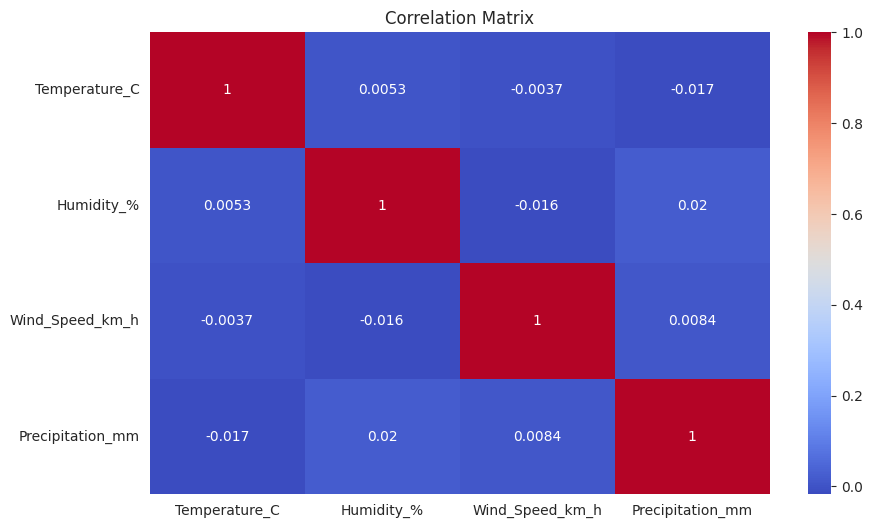

In [9]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

<div class='section'>Distribution Analysis</div>

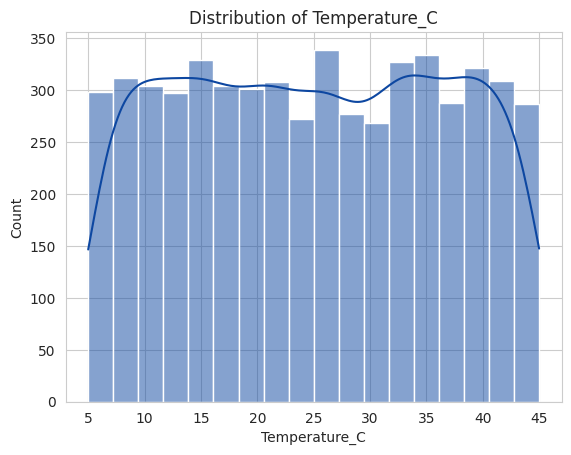

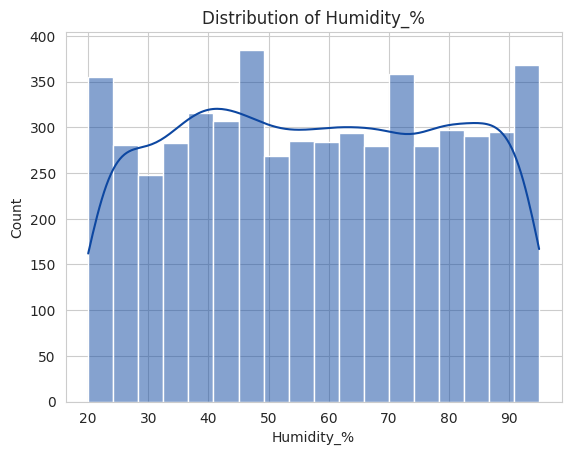

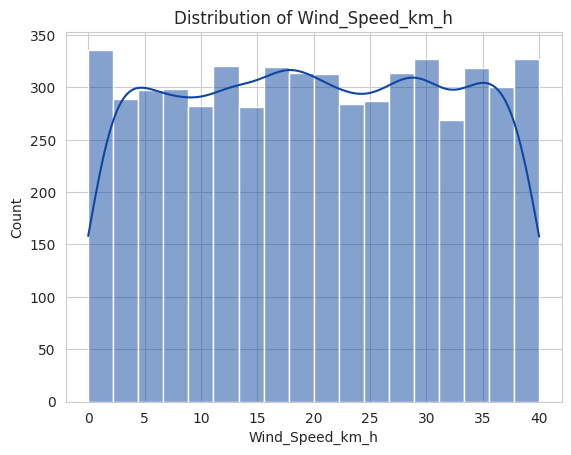

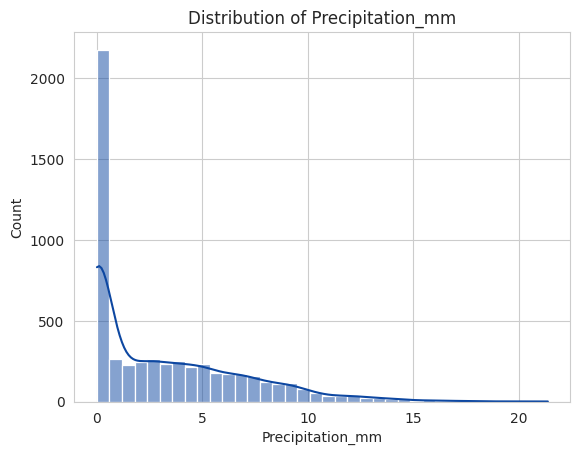

In [10]:
for col in num_df.columns:
    plt.figure()
    sns.histplot(df[col],kde=True,color="#0d47a1")
    plt.title(f"Distribution of {col}")
    plt.show()

<div class='section'>Boxplot Outlier Detection</div>

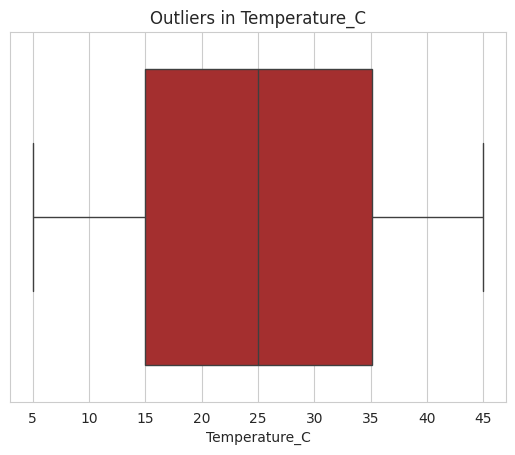

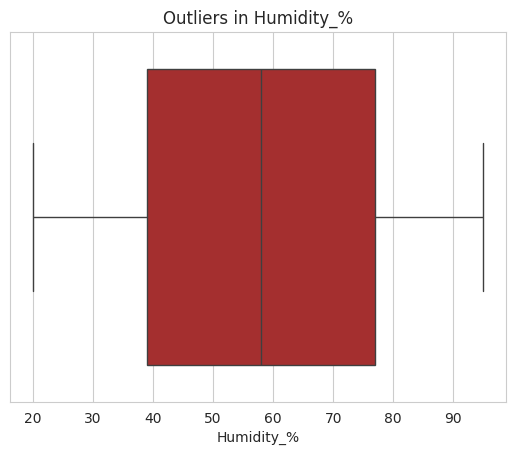

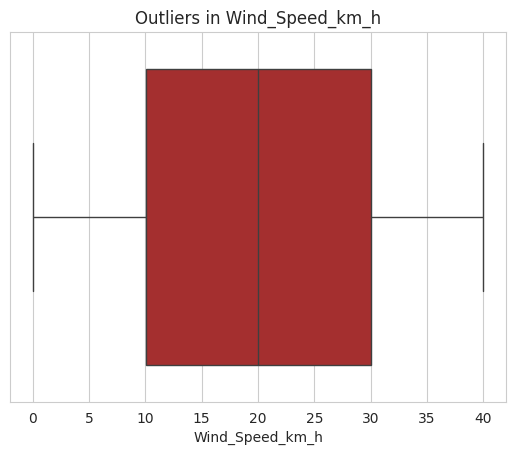

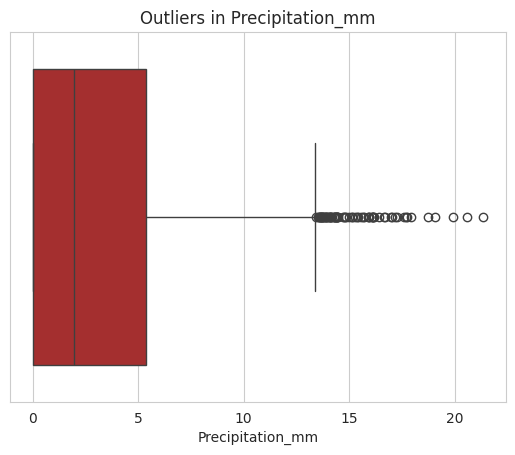

In [11]:
for col in num_df.columns:
    plt.figure()
    sns.boxplot(x=df[col],color="#b71c1c")
    plt.title(f"Outliers in {col}")
    plt.show()

<div class='section'>Pairplot Relationship Analysis</div>

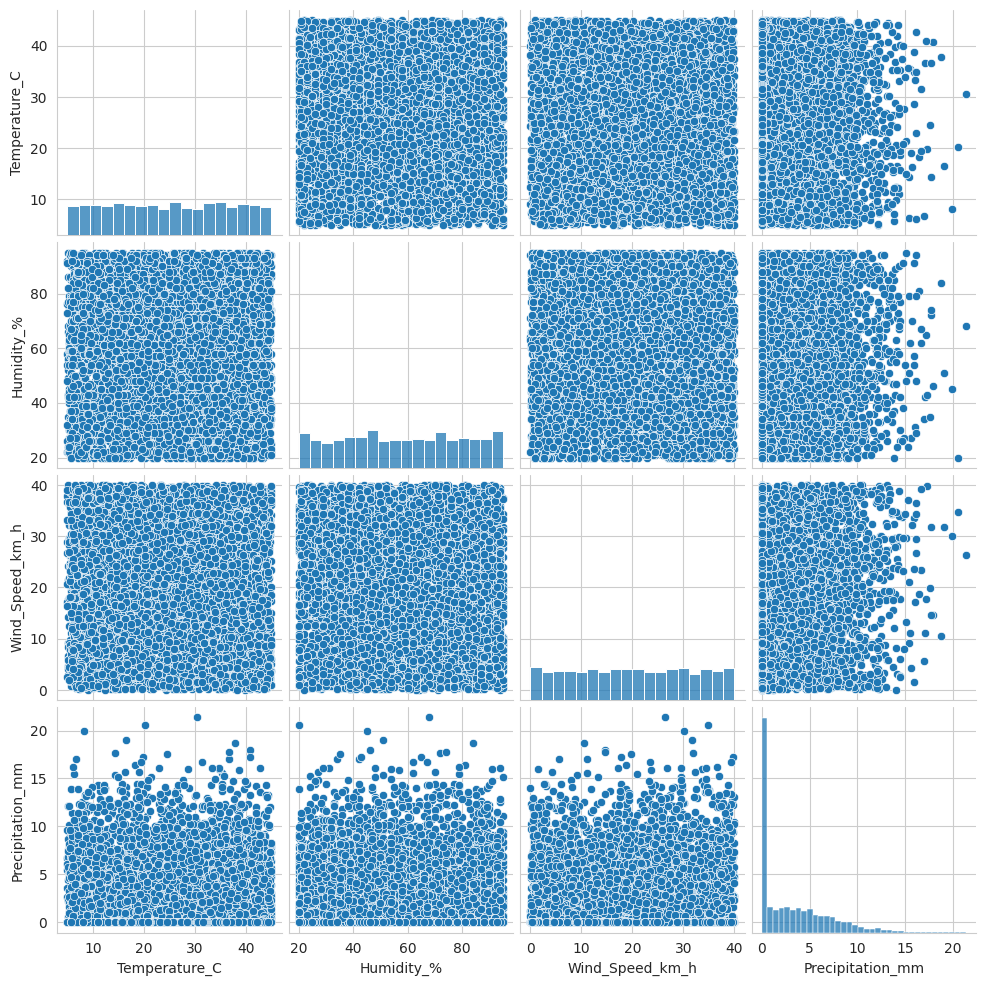

In [12]:
sns.pairplot(num_df)
plt.show()

<div class='section'>Interactive Plotly Visualizations</div>

In [13]:
for col in num_df.columns:

    fig = px.histogram(
        df,
        x=col,
        color_discrete_sequence=["#0d47a1"]
    )

    fig.update_layout(
        title=f"{col} Distribution",
        template="plotly_white"
    )

    fig.show(renderer='iframe')


In [14]:
if len(num_df.columns) >= 2:

    fig = px.scatter(
        df,
        x=num_df.columns[0],
        y=num_df.columns[1],
        color_discrete_sequence=["#b71c1c"]
    )

    fig.update_layout(
        title="Feature Relationship",
        template="plotly_white"
    )

    fig.show(renderer='iframe')


<div class='section'>Trend Visualization</div>

In [15]:
if 'Date' in df.columns:

    fig = px.line(
        df,
        x="Date",
        y=num_df.columns[0],
        color_discrete_sequence=["#0d47a1"]
    )

    fig.update_layout(title="Time Series Trend")

    fig.show(renderer='iframe')



<div class='section'>Key Insights</div>

<div class='box'>

• Dataset structure and statistical distribution explored.

• Correlation heatmap reveals relationships between numerical variables.

• Boxplots identify potential outliers in weather measurements.

• Interactive charts provide deeper understanding of weather patterns.

</div>
